# 04 — Integração OCDE + Banco Mundial (versão revisada)

Este notebook integra a base setorial da OCDE, já preparada no notebook `01_preparacao_dados_ocde_explicado.ipynb`, com os indicadores macroeconômicos e digitais obtidos pelo grupo a partir do Banco Mundial.

A proposta aqui é **não alterar a lógica do projeto ainda**. Este notebook não incorpora automaticamente os indicadores do Banco Mundial ao modelo de Market Twin. Ele apenas cria uma base integrada, valida a compatibilidade entre as fontes e avalia se a junção é segura.

A ideia metodológica é simples: a OCDE continua sendo a base principal, porque ela contém os indicadores específicos do setor de software. O Banco Mundial entra como uma camada complementar de contexto econômico e digital dos países.

Assim, a integração segue a estrutura da OCDE: mantemos apenas os países e anos que já existem na base OCDE preparada e adicionamos as variáveis do Banco Mundial correspondentes aos mesmos pares país-ano.

## 1. Objetivo da integração

O objetivo desta etapa é produzir uma base combinada que una duas dimensões do projeto.

A primeira dimensão é setorial. Ela vem da OCDE e descreve o setor de software por meio de variáveis como número de empresas, valor econômico, empregados, produtividade aparente e tamanho médio das firmas.

A segunda dimensão é contextual. Ela vem do Banco Mundial e descreve o ambiente macroeconômico e digital dos países, com indicadores como uso de internet, PIB per capita, banda larga, PIB total e servidores seguros.

A integração permite que análises futuras avaliem não apenas a estrutura do setor de software, mas também o contexto econômico e digital no qual esse setor está inserido.

## 1.1. Nota metodológica sobre o recorte da integração

A base do Banco Mundial contém muito mais países do que a base da OCDE. Mesmo assim, neste notebook a OCDE é mantida como base principal da integração. Isso significa que a base integrada final preserva apenas os países e anos que já existem na base OCDE preparada.

Essa decisão é intencional. A OCDE fornece os indicadores setoriais do mercado de software, enquanto o Banco Mundial fornece variáveis macroeconômicas e digitais de contexto. Portanto, não faria sentido expandir a base integrada para países que possuem indicadores do Banco Mundial, mas não possuem os indicadores setoriais da OCDE usados no projeto.

Assim, a integração deve ser interpretada como:

**OCDE = núcleo setorial do mercado de software**  
**Banco Mundial = camada contextual macroeconômica e digital**

Essa escolha reduz o tamanho da amostra em relação à base completa do Banco Mundial, mas preserva a consistência do objetivo do projeto.

In [1]:
# Bibliotecas principais
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import pairwise_distances

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

print('Ambiente carregado com sucesso.')

Ambiente carregado com sucesso.


## 2. Localização dos arquivos de entrada

Este notebook espera dois arquivos principais.

O primeiro é a base OCDE preparada corrigida, gerada pelo notebook de preparação dos dados. O segundo é a base do Banco Mundial enviada pelo grupo.

Para facilitar a execução no Colab ou em ambientes locais, a célula abaixo procura variações comuns dos nomes dos arquivos. Isso evita erro caso o arquivo tenha sido baixado com sufixos como `(1)`.

In [2]:
def encontrar_arquivo(candidatos):
    """Retorna o primeiro arquivo existente a partir de uma lista de nomes candidatos."""
    for nome in candidatos:
        caminho = Path(nome)
        if caminho.exists():
            return caminho
    raise FileNotFoundError(f'Nenhum dos arquivos foi encontrado: {candidatos}')

arquivo_ocde = encontrar_arquivo([
    'dados_ocde_preparado_corrigido.csv',
    'dados_ocde_preparado_corrigido(1).csv',
    '/mnt/data/dados_ocde_preparado_corrigido.csv',
])

arquivo_bm = encontrar_arquivo([
    'dados_paises_com_regiao.csv',
    'dados_paises_com_regiao(1).csv',
    '/mnt/data/dados_paises_com_regiao.csv',
    '/mnt/data/dados_paises_com_regiao(1).csv',
])

print('Arquivo OCDE encontrado:', arquivo_ocde)
print('Arquivo Banco Mundial encontrado:', arquivo_bm)

Arquivo OCDE encontrado: dados_ocde_preparado_corrigido.csv
Arquivo Banco Mundial encontrado: dados_paises_com_regiao.csv


## 3. Carregamento das bases

Nesta etapa, carregamos as duas bases e fazemos uma primeira inspeção de tamanho, colunas e tipos de dados.

A base OCDE deve estar no formato país-ano, com a coluna `Pais` representando o código ISO de três letras e `Ano` representando o ano. A base do Banco Mundial deve ter `Country_Code` e `Year`, que cumprem a mesma função.

In [3]:
df_ocde = pd.read_csv(arquivo_ocde)
df_bm = pd.read_csv(arquivo_bm)

print('Base OCDE:', df_ocde.shape)
print('Base Banco Mundial:', df_bm.shape)

print('\nColunas OCDE:')
print(df_ocde.columns.tolist())

print('\nColunas Banco Mundial:')
print(df_bm.columns.tolist())

display(df_ocde.head())
display(df_bm.head())

Base OCDE: (444, 10)
Base Banco Mundial: (3255, 10)

Colunas OCDE:
['Pais', 'Ano', 'ENTR', 'TUTT', 'EMPE', 'Flag_TUTT_Zero_Suspeito', 'Flag_TUTT_Ausente_Ou_Imputado', 'Flag_Outlier_Prod', 'PROD', 'TAMANHO_MEDIO']

Colunas Banco Mundial:
['Country_Name', 'Country_Code', 'Region', 'Income_Group', 'Year', 'Internet_Usage_Pct', 'GDP_Per_Capita_PPP', 'Broadband_Subscriptions', 'GDP_USD', 'Secure_Servers']


,Pais,Ano,ENTR,TUTT,EMPE,Flag_TUTT_Zero_Suspeito,Flag_TUTT_Ausente_Ou_Imputado,Flag_Outlier_Prod,PROD,TAMANHO_MEDIO
0,AUT,2010,12849.0,7355.600098,41793.0,0,0,0,0.176001,3.252627
1,AUT,2011,13227.0,8683.399902,45761.0,0,0,0,0.189755,3.459666
2,AUT,2012,13545.0,9283.199707,48444.0,0,0,0,0.191627,3.576523
3,AUT,2013,13863.0,10036.300049,50439.0,0,0,0,0.198979,3.638390
4,AUT,2014,14236.0,10808.200195,53606.0,0,0,0,0.201623,3.765524


,Country_Name,Country_Code,Region,Income_Group,Year,Internet_Usage_Pct,GDP_Per_Capita_PPP,Broadband_Subscriptions,GDP_USD,Secure_Servers
0,American Samoa,ASM,East Asia & Pacific,High income,2010,NaN,NaN,NaN,573000000.0,54.320272
1,American Samoa,ASM,East Asia & Pacific,High income,2011,NaN,NaN,NaN,570000000.0,18.216595
2,American Samoa,ASM,East Asia & Pacific,High income,2012,NaN,NaN,NaN,640000000.0,18.352328
3,American Samoa,ASM,East Asia & Pacific,High income,2013,NaN,NaN,NaN,638000000.0,0.000000
4,American Samoa,ASM,East Asia & Pacific,High income,2014,NaN,NaN,NaN,643000000.0,448.883403


## 4. Padronização básica da base do Banco Mundial

Antes da junção, fazemos uma limpeza simples na base do Banco Mundial.

Os códigos de país são padronizados como texto sem espaços extras. As colunas de região e grupo de renda também são limpas para evitar diferenças artificiais causadas por espaços no começo ou no fim do texto.

Além disso, garantimos que o ano está em formato numérico inteiro e que os indicadores quantitativos estão como variáveis numéricas.

In [4]:
df_bm_limpo = df_bm.copy()

# Limpeza de textos
for col in ['Country_Name', 'Country_Code', 'Region', 'Income_Group']:
    if col in df_bm_limpo.columns:
        df_bm_limpo[col] = df_bm_limpo[col].astype(str).str.strip()

# Ano como inteiro
if 'Year' in df_bm_limpo.columns:
    df_bm_limpo['Year'] = pd.to_numeric(df_bm_limpo['Year'], errors='coerce').astype('Int64')

# Indicadores numéricos do Banco Mundial
indicadores_bm = [
    'Internet_Usage_Pct',
    'GDP_Per_Capita_PPP',
    'Broadband_Subscriptions',
    'GDP_USD',
    'Secure_Servers'
]

for col in indicadores_bm:
    df_bm_limpo[col] = pd.to_numeric(df_bm_limpo[col], errors='coerce')

# Padronização da OCDE
df_ocde_limpo = df_ocde.copy()
df_ocde_limpo['Pais'] = df_ocde_limpo['Pais'].astype(str).str.strip()
df_ocde_limpo['Ano'] = pd.to_numeric(df_ocde_limpo['Ano'], errors='coerce').astype('Int64')

print('Limpeza básica concluída.')
print('\nRegiões encontradas na base Banco Mundial:')
print(sorted(df_bm_limpo['Region'].dropna().unique()))

print('\nGrupos de renda encontrados:')
print(sorted(df_bm_limpo['Income_Group'].dropna().unique()))

Limpeza básica concluída.

Regiões encontradas na base Banco Mundial:
['East Asia & Pacific', 'Europe & Central Asia', 'Latin America & Caribbean', 'Middle East, North Africa, Afghanistan & Pakistan', 'North America', 'South Asia', 'Sub-Saharan Africa']

Grupos de renda encontrados:
['High income', 'Low income', 'Lower middle income', 'Not classified', 'Upper middle income']


## 5. Validação das chaves de junção

A integração será feita por país e ano.

Na base OCDE, a chave é `Pais` + `Ano`. Na base do Banco Mundial, a chave equivalente é `Country_Code` + `Year`.

Antes de juntar as bases, verificamos se existem duplicatas nessas chaves. Duplicatas seriam problemáticas porque poderiam fazer uma linha da OCDE se multiplicar indevidamente após a junção.

In [5]:
# Checagem de duplicatas nas chaves
num_dup_ocde = df_ocde_limpo.duplicated(['Pais', 'Ano']).sum()
num_dup_bm = df_bm_limpo.duplicated(['Country_Code', 'Year']).sum()

print(f'Duplicatas OCDE em Pais+Ano: {num_dup_ocde}')
print(f'Duplicatas Banco Mundial em Country_Code+Year: {num_dup_bm}')

if num_dup_ocde > 0:
    print('\nExemplos de duplicatas na OCDE:')
    display(df_ocde_limpo[df_ocde_limpo.duplicated(['Pais', 'Ano'], keep=False)].sort_values(['Pais', 'Ano']).head(20))

if num_dup_bm > 0:
    print('\nExemplos de duplicatas no Banco Mundial:')
    display(df_bm_limpo[df_bm_limpo.duplicated(['Country_Code', 'Year'], keep=False)].sort_values(['Country_Code', 'Year']).head(20))

Duplicatas OCDE em Pais+Ano: 0
Duplicatas Banco Mundial em Country_Code+Year: 0


## 6. Verificação de compatibilidade entre as bases

Nesta etapa, verificamos se todos os países da OCDE aparecem na base do Banco Mundial e se os anos necessários estão disponíveis.

O objetivo não é usar todos os países do Banco Mundial. A base integrada deve seguir a base OCDE, porque a OCDE contém os indicadores setoriais do projeto. O Banco Mundial apenas adiciona contexto para os mesmos países e anos.

In [6]:
paises_ocde = set(df_ocde_limpo['Pais'].dropna().unique())
paises_bm = set(df_bm_limpo['Country_Code'].dropna().unique())

paises_faltantes_no_bm = sorted(paises_ocde - paises_bm)
paises_extras_no_bm = sorted(paises_bm - paises_ocde)

print(f'Países na base OCDE preparada: {len(paises_ocde)}')
print(f'Países na base Banco Mundial completa: {len(paises_bm)}')
print(f'Países da OCDE ausentes no Banco Mundial: {len(paises_faltantes_no_bm)}')
print(paises_faltantes_no_bm)

print('\nIntervalo de anos OCDE:')
print(int(df_ocde_limpo['Ano'].min()), 'a', int(df_ocde_limpo['Ano'].max()))

print('\nIntervalo de anos Banco Mundial:')
print(int(df_bm_limpo['Year'].min()), 'a', int(df_bm_limpo['Year'].max()))

Países na base OCDE preparada: 35
Países na base Banco Mundial completa: 217
Países da OCDE ausentes no Banco Mundial: 0
[]

Intervalo de anos OCDE:
2010 a 2022

Intervalo de anos Banco Mundial:
2010 a 2024


## 7. Junção das bases

A junção é feita como uma junção à esquerda a partir da base OCDE.

Isso significa que todas as linhas da OCDE são preservadas. Para cada linha da OCDE, procuramos o registro correspondente no Banco Mundial com o mesmo país e o mesmo ano.

Essa estratégia é importante porque evita expandir artificialmente a base com países ou anos que existem no Banco Mundial, mas não possuem indicadores setoriais da OCDE.

In [7]:
df_integrado = df_ocde_limpo.merge(
    df_bm_limpo,
    left_on=['Pais', 'Ano'],
    right_on=['Country_Code', 'Year'],
    how='left',
    indicator=True
)

print('Linhas da OCDE antes da integração:', len(df_ocde_limpo))
print('Linhas após integração:', len(df_integrado))
print('\nResultado da junção:')
print(df_integrado['_merge'].value_counts())

nao_encontradas = df_integrado[df_integrado['_merge'] != 'both']
if len(nao_encontradas) > 0:
    print('\nLinhas da OCDE sem correspondência no Banco Mundial:')
    display(nao_encontradas[['Pais', 'Ano']].head(50))
else:
    print('\nTodas as linhas da OCDE encontraram correspondência no Banco Mundial.')

Linhas da OCDE antes da integração: 444
Linhas após integração: 444

Resultado da junção:
_merge
both          444
left_only       0
right_only      0
Name: count, dtype: int64

Todas as linhas da OCDE encontraram correspondência no Banco Mundial.


## 8. Organização da base integrada

Depois da junção, removemos colunas duplicadas de chave e organizamos a ordem das colunas.

A base final mantém os indicadores setoriais da OCDE, as flags criadas na preparação e os indicadores contextuais do Banco Mundial.

In [8]:
# Remoção de colunas auxiliares da junção
cols_remover = ['Country_Code', 'Year', '_merge']
df_integrado = df_integrado.drop(columns=[c for c in cols_remover if c in df_integrado.columns])

# Ordem sugerida das colunas
colunas_id = ['Pais', 'Country_Name', 'Region', 'Income_Group', 'Ano']
colunas_ocde = ['ENTR', 'TUTT', 'EMPE', 'PROD', 'TAMANHO_MEDIO']
colunas_flags = ['Flag_TUTT_Zero_Suspeito', 'Flag_TUTT_Ausente_Ou_Imputado', 'Flag_Outlier_Prod']
colunas_bm = indicadores_bm

ordem = colunas_id + colunas_ocde + colunas_flags + colunas_bm
ordem_existente = [c for c in ordem if c in df_integrado.columns]
outras = [c for c in df_integrado.columns if c not in ordem_existente]

df_integrado = df_integrado[ordem_existente + outras]

print('Base integrada organizada:', df_integrado.shape)
display(df_integrado.head())

Base integrada organizada: (444, 18)


,Pais,Country_Name,Region,Income_Group,Ano,ENTR,TUTT,EMPE,PROD,TAMANHO_MEDIO,Flag_TUTT_Zero_Suspeito,Flag_TUTT_Ausente_Ou_Imputado,Flag_Outlier_Prod,Internet_Usage_Pct,GDP_Per_Capita_PPP,Broadband_Subscriptions,GDP_USD,Secure_Servers
0,AUT,Austria,Europe & Central Asia,High income,2010,12849.0,7355.600098,41793.0,0.176001,3.252627,0,0,0,75.170000,41735.457480,24.511386,3.898278e+11,690.149609
1,AUT,Austria,Europe & Central Asia,High income,2011,13227.0,8683.399902,45761.0,0.189755,3.459666,0,0,0,78.739993,44171.561869,24.992643,4.289547e+11,1068.443927
2,AUT,Austria,Europe & Central Asia,High income,2012,13545.0,9283.199707,48444.0,0.191627,3.576523,0,0,0,80.029994,46156.483207,25.264478,4.067505e+11,1613.406230
3,AUT,Austria,Europe & Central Asia,High income,2013,13863.0,10036.300049,50439.0,0.198979,3.638390,0,0,0,80.618800,47519.852280,26.322287,4.265805e+11,1857.468016
4,AUT,Austria,Europe & Central Asia,High income,2014,14236.0,10808.200195,53606.0,0.201623,3.765524,0,0,0,80.995825,48355.497762,27.597690,4.385560e+11,2345.327061


## 9. Análise de cobertura da base integrada

Aqui verificamos se, após a integração, restaram valores ausentes nos indicadores principais.

Essa etapa é importante porque a base integrada só é útil para modelagem se os indicadores do Banco Mundial estiverem disponíveis para os mesmos países e anos da OCDE.

In [9]:
colunas_criticas = colunas_ocde + colunas_bm

relatorio_ausentes = (
    df_integrado[colunas_criticas]
    .isna()
    .sum()
    .rename('n_ausentes')
    .reset_index()
    .rename(columns={'index': 'variavel'})
)
relatorio_ausentes['perc_ausente'] = relatorio_ausentes['n_ausentes'] / len(df_integrado) * 100
relatorio_ausentes['n_validos'] = len(df_integrado) - relatorio_ausentes['n_ausentes']
relatorio_ausentes = relatorio_ausentes[['variavel', 'n_validos', 'n_ausentes', 'perc_ausente']]

print('Cobertura das variáveis críticas na base integrada:')
display(relatorio_ausentes)

if relatorio_ausentes['n_ausentes'].sum() == 0:
    print('\nNão há valores ausentes nas variáveis críticas da base integrada.')
else:
    print('\nAtenção: há valores ausentes em variáveis críticas.')

Cobertura das variáveis críticas na base integrada:


,variavel,n_validos,n_ausentes,perc_ausente
0,ENTR,444,0,0.0
1,TUTT,444,0,0.0
2,EMPE,444,0,0.0
3,PROD,444,0,0.0
4,TAMANHO_MEDIO,444,0,0.0
5,Internet_Usage_Pct,444,0,0.0
6,GDP_Per_Capita_PPP,444,0,0.0
7,Broadband_Subscriptions,444,0,0.0
8,GDP_USD,444,0,0.0
9,Secure_Servers,444,0,0.0



Não há valores ausentes nas variáveis críticas da base integrada.


## 10. Cobertura por país

Além da cobertura por variável, também é útil verificar a cobertura por país. Essa tabela mostra quantos anos cada país possui na base integrada e confirma se os indicadores do Banco Mundial estão completos dentro do recorte da OCDE.

In [10]:
cobertura_pais = (
    df_integrado
    .groupby(['Pais', 'Country_Name', 'Region', 'Income_Group'], dropna=False)
    .agg(
        ano_min=('Ano', 'min'),
        ano_max=('Ano', 'max'),
        n_anos=('Ano', 'nunique'),
        ausentes_bm=('Internet_Usage_Pct', lambda s: int(s.isna().sum()))
    )
    .reset_index()
    .sort_values(['Pais'])
)

print('Resumo de cobertura por país:')
display(cobertura_pais.head(40))

print('\nDistribuição do número de anos por país:')
display(cobertura_pais['n_anos'].value_counts().sort_index().rename('n_paises').reset_index().rename(columns={'index': 'n_anos'}))

Resumo de cobertura por país:


,Pais,Country_Name,Region,Income_Group,ano_min,ano_max,n_anos,ausentes_bm
0,AUT,Austria,Europe & Central Asia,High income,2010,2022,13,0
1,BEL,Belgium,Europe & Central Asia,High income,2010,2022,13,0
2,BGR,Bulgaria,Europe & Central Asia,High income,2010,2022,13,0
3,BIH,Bosnia and Herzegovina,Europe & Central Asia,Upper middle income,2011,2022,12,0
4,BRA,Brazil,Latin America & Caribbean,Upper middle income,2010,2021,12,0
5,CRI,Costa Rica,Latin America & Caribbean,High income,2010,2022,13,0
6,CYP,Cyprus,Europe & Central Asia,High income,2010,2022,13,0
7,CZE,Czechia,Europe & Central Asia,High income,2010,2022,13,0
8,DEU,Germany,Europe & Central Asia,High income,2010,2022,13,0
9,DNK,Denmark,Europe & Central Asia,High income,2010,2022,13,0



Distribuição do número de anos por país:


,n_anos,n_paises
0,8,1
1,10,1
2,12,3
3,13,30


## 11. Relevância dos indicadores do Banco Mundial para o projeto

Os indicadores do Banco Mundial não substituem os indicadores setoriais da OCDE. Eles cumprem outro papel: descrevem o ambiente econômico e digital no qual o setor de software existe.

Assim, a leitura recomendada é:

- A OCDE descreve o setor de software.
- O Banco Mundial descreve o contexto do país.

Essa distinção é importante para não confundir variáveis setoriais com variáveis macroeconômicas ou de infraestrutura digital.

Nesta versão revisada, dois cuidados adicionais são explicitados:

1. `Internet_Usage_Pct` é uma porcentagem limitada entre 0 e 100. Por isso, na base auxiliar de modelagem ela não recebe transformação logarítmica; recebe apenas normalização robusta.
2. `Secure_Servers` é mantida como variável contextual, mas é tratada com cautela porque costuma ter distribuição muito assimétrica e pode apresentar variações fortes ao longo do tempo. Por isso, o notebook inclui uma seção específica de diagnóstico e sensibilidade para essa variável.

In [11]:
relevancia = pd.DataFrame([
    {
        'Indicador': 'Internet_Usage_Pct',
        'Dimensao': 'Digitalização geral',
        'Interpretacao': 'Percentual da população usando internet; aproxima o grau de difusão digital do país.',
        'Uso_potencial': 'Contextualizar mercados de software em países com maior ou menor base de usuários digitais.',
        'Cuidado': 'Não mede diretamente empresas de software; é indicador de ambiente digital geral.'
    },
    {
        'Indicador': 'GDP_Per_Capita_PPP',
        'Dimensao': 'Desenvolvimento econômico',
        'Interpretacao': 'PIB per capita ajustado por paridade de poder de compra; aproxima renda e capacidade econômica média.',
        'Uso_potencial': 'Controlar ou contextualizar diferenças de desenvolvimento econômico entre países.',
        'Cuidado': 'É macroeconômico; não mede especificamente o setor de software.'
    },
    {
        'Indicador': 'Broadband_Subscriptions',
        'Dimensao': 'Infraestrutura digital',
        'Interpretacao': 'Assinaturas de banda larga; aproxima disponibilidade/adoção de infraestrutura de conectividade.',
        'Uso_potencial': 'Avaliar se mercados de software se desenvolvem em ambientes com maior conectividade.',
        'Cuidado': 'Pode variar por definição de assinatura e população; precisa de normalização.'
    },
    {
        'Indicador': 'GDP_USD',
        'Dimensao': 'Escala macroeconômica',
        'Interpretacao': 'Tamanho da economia em dólares correntes; aproxima escala econômica geral do país.',
        'Uso_potencial': 'Diferenciar economias grandes e pequenas no contexto macro.',
        'Cuidado': 'Escala muito alta; pode dominar modelos se não for transformado.'
    },
    {
        'Indicador': 'Secure_Servers',
        'Dimensao': 'Infraestrutura digital segura',
        'Interpretacao': 'Quantidade ou densidade de servidores seguros; aproxima presença de infraestrutura online segura.',
        'Uso_potencial': 'Contextualizar maturidade de serviços digitais e ambiente online.',
        'Cuidado': 'Distribuição muito assimétrica e potencialmente irregular; requer log-transform, normalização robusta e análise de sensibilidade.'
    }
])

display(relevancia)

,Indicador,Dimensao,Interpretacao,Uso_potencial,Cuidado
0,Internet_Usage_Pct,Digitalização geral,Percentual da população usando internet; aprox...,Contextualizar mercados de software em países ...,Não mede diretamente empresas de software; é i...
1,GDP_Per_Capita_PPP,Desenvolvimento econômico,PIB per capita ajustado por paridade de poder ...,Controlar ou contextualizar diferenças de dese...,É macroeconômico; não mede especificamente o s...
2,Broadband_Subscriptions,Infraestrutura digital,Assinaturas de banda larga; aproxima disponibi...,Avaliar se mercados de software se desenvolvem...,Pode variar por definição de assinatura e popu...
3,GDP_USD,Escala macroeconômica,Tamanho da economia em dólares correntes; apro...,Diferenciar economias grandes e pequenas no co...,Escala muito alta; pode dominar modelos se não...
4,Secure_Servers,Infraestrutura digital segura,Quantidade ou densidade de servidores seguros;...,Contextualizar maturidade de serviços digitais...,Distribuição muito assimétrica e potencialment...


## 12. Estatísticas descritivas dos indicadores integrados

Esta etapa apresenta uma visão resumida das variáveis principais da base integrada. A intenção é detectar escalas muito diferentes, valores extremos e possíveis variáveis que exigem transformação antes de uso em modelos.

Indicadores como PIB em dólares e servidores seguros geralmente têm distribuição muito assimétrica. Por isso, eles não devem entrar em modelos baseados em distância sem transformação e normalização.

,count,mean,std,min,25%,50%,75%,max
ENTR,444.0,2.770767e+04,3.513385e+04,6.100000e+01,5.020250e+03,1.156650e+04,3.814150e+04,1.766420e+05
TUTT,444.0,1.230624e+05,3.547994e+05,2.796848e+01,2.287800e+03,1.885116e+04,8.772629e+04,3.284919e+06
EMPE,444.0,1.205339e+05,1.799525e+05,4.810000e+02,1.494700e+04,5.198450e+04,1.157012e+05,1.014270e+06
PROD,444.0,2.874468e+00,8.430686e+00,3.326695e-02,1.103984e-01,2.013658e-01,8.843169e-01,4.779590e+01
TAMANHO_MEDIO,444.0,4.397266e+00,1.814716e+00,5.941512e-01,2.838137e+00,4.180793e+00,5.599220e+00,9.333916e+00
Internet_Usage_Pct,444.0,7.819098e+01,1.405315e+01,3.650000e+01,6.988223e+01,8.065348e+01,8.927447e+01,9.968702e+01
GDP_Per_Capita_PPP,444.0,4.050751e+04,2.136040e+04,9.761476e+03,2.657485e+04,3.717268e+04,4.878875e+04,1.469191e+05
Broadband_Subscriptions,444.0,2.945048e+01,8.824359e+00,7.279685e+00,2.339671e+01,2.924400e+01,3.665126e+01,4.825023e+01
GDP_USD,444.0,6.123728e+11,9.235618e+11,9.097044e+09,5.385471e+10,2.335612e+11,5.757354e+11,4.355252e+12
Secure_Servers,444.0,1.978145e+04,3.700418e+04,1.763858e+01,7.464747e+02,3.389994e+03,2.412564e+04,2.773306e+05


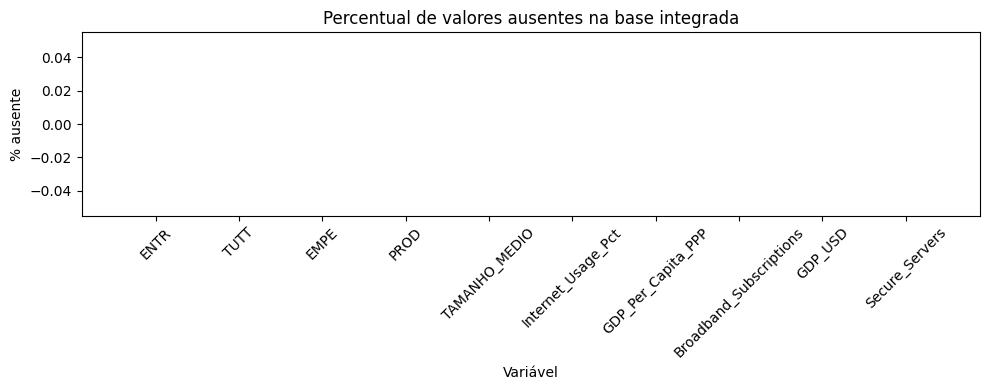

In [12]:
descricao = df_integrado[colunas_criticas].describe().T

display(descricao)

# Gráfico simples de ausência por variável
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(relatorio_ausentes['variavel'], relatorio_ausentes['perc_ausente'])
ax.set_title('Percentual de valores ausentes na base integrada')
ax.set_ylabel('% ausente')
ax.set_xlabel('Variável')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 13. Exportação da base integrada

A base integrada principal é exportada em escala original. Ela é a base recomendada para inspeção, documentação, análises econômicas e futuras etapas de modelagem.

Essa base ainda não aplica transformação logarítmica nem normalização nos indicadores do Banco Mundial. Essa decisão é intencional: a base integrada deve preservar os valores originais para facilitar interpretação e auditoria.

In [13]:
saida_integrada = 'dados_ocde_banco_mundial_integrado.csv'
df_integrado.to_csv(saida_integrada, index=False)

print(f'Base integrada exportada: {saida_integrada}')
print('Dimensão:', df_integrado.shape)

Base integrada exportada: dados_ocde_banco_mundial_integrado.csv
Dimensão: (444, 18)


## 14. Diagnóstico específico da variável `Secure_Servers`

A variável `Secure_Servers` é potencialmente útil porque aproxima a presença de infraestrutura digital segura no país. Porém, ela merece cautela antes de entrar em modelos, pois costuma ter distribuição muito assimétrica e pode variar fortemente entre países e anos.

Por esse motivo, esta seção faz um diagnóstico simples antes de gerar a base auxiliar de modelagem. O objetivo não é excluir automaticamente a variável, mas verificar se ela apresenta comportamento extremo a ponto de dominar modelos baseados em distância.

A análise abaixo observa:

- estatísticas descritivas da variável em escala original;
- estatísticas após transformação logarítmica;
- variações ano a ano por país;
- maiores saltos observados na série.

Se `Secure_Servers` alterar muito os resultados de modelagem, ela deve ser tratada como variável de contexto ou usada em análises de sensibilidade, e não necessariamente como variável central do Market Twin.

In [14]:
# Diagnóstico específico de Secure_Servers
secure = df_integrado[['Pais', 'Country_Name', 'Region', 'Income_Group', 'Ano', 'Secure_Servers']].copy()
secure = secure.sort_values(['Pais', 'Ano'])
secure['Secure_Servers_log1p'] = np.log1p(secure['Secure_Servers'])

# Variação anual em escala logarítmica. Essa métrica é mais estável do que variação percentual simples.
secure['Delta_Log_Secure_Servers'] = secure.groupby('Pais')['Secure_Servers_log1p'].diff()
secure['Abs_Delta_Log_Secure_Servers'] = secure['Delta_Log_Secure_Servers'].abs()

secure_stats = pd.DataFrame({
    'metrica': ['min', 'p25', 'mediana', 'media', 'p75', 'p95', 'p99', 'max'],
    'Secure_Servers': [
        secure['Secure_Servers'].min(),
        secure['Secure_Servers'].quantile(0.25),
        secure['Secure_Servers'].median(),
        secure['Secure_Servers'].mean(),
        secure['Secure_Servers'].quantile(0.75),
        secure['Secure_Servers'].quantile(0.95),
        secure['Secure_Servers'].quantile(0.99),
        secure['Secure_Servers'].max(),
    ],
    'Secure_Servers_log1p': [
        secure['Secure_Servers_log1p'].min(),
        secure['Secure_Servers_log1p'].quantile(0.25),
        secure['Secure_Servers_log1p'].median(),
        secure['Secure_Servers_log1p'].mean(),
        secure['Secure_Servers_log1p'].quantile(0.75),
        secure['Secure_Servers_log1p'].quantile(0.95),
        secure['Secure_Servers_log1p'].quantile(0.99),
        secure['Secure_Servers_log1p'].max(),
    ]
})

saltos_secure = (
    secure.dropna(subset=['Delta_Log_Secure_Servers'])
    .sort_values('Abs_Delta_Log_Secure_Servers', ascending=False)
    .head(15)
    [['Pais', 'Country_Name', 'Ano', 'Secure_Servers', 'Secure_Servers_log1p', 'Delta_Log_Secure_Servers', 'Abs_Delta_Log_Secure_Servers']]
)

resumo_secure_pais = (
    secure.groupby(['Pais', 'Country_Name'], dropna=False)
    .agg(
        secure_min=('Secure_Servers', 'min'),
        secure_mediana=('Secure_Servers', 'median'),
        secure_max=('Secure_Servers', 'max'),
        delta_log_abs_medio=('Abs_Delta_Log_Secure_Servers', 'mean'),
        delta_log_abs_max=('Abs_Delta_Log_Secure_Servers', 'max')
    )
    .reset_index()
    .sort_values('delta_log_abs_max', ascending=False)
)

print('Estatísticas descritivas de Secure_Servers:')
display(secure_stats)

print('Maiores saltos ano a ano em escala logarítmica:')
display(saltos_secure)

print('Países com maior variação máxima ano a ano em Secure_Servers:')
display(resumo_secure_pais.head(15))

secure_stats.to_csv('diagnostico_secure_servers_estatisticas.csv', index=False)
saltos_secure.to_csv('diagnostico_secure_servers_maiores_saltos.csv', index=False)
resumo_secure_pais.to_csv('diagnostico_secure_servers_por_pais.csv', index=False)

print('Relatórios de diagnóstico de Secure_Servers exportados.')

Estatísticas descritivas de Secure_Servers:


,metrica,Secure_Servers,Secure_Servers_log1p
0,min,17.638579,2.925234
1,p25,746.474681,6.616626
2,mediana,3389.994152,8.128877
3,media,19781.448806,8.259424
4,p75,24125.639812,10.091072
5,p95,85185.178548,11.352586
6,p99,173852.168131,12.064775
7,max,277330.575593,12.532969


Maiores saltos ano a ano em escala logarítmica:


,Pais,Country_Name,Ano,Secure_Servers,Secure_Servers_log1p,Delta_Log_Secure_Servers,Abs_Delta_Log_Secure_Servers
385,ROU,Romania,2016,3421.484441,8.138122,2.245842,2.245842
210,HRV,Croatia,2017,14908.421745,9.609749,2.140141,2.140141
33,BGR,Bulgaria,2017,33602.274605,10.422379,2.083952,2.083952
45,BIH,Bosnia and Herzegovina,2017,1465.286078,7.290488,2.071741,2.071741
32,BGR,Bulgaria,2016,4180.507530,8.338427,1.787750,1.787750
257,ITA,Italy,2017,7813.040084,8.963677,1.780397,1.780397
95,CZE,Czechia,2016,11991.389254,9.392027,1.766519,1.766519
243,ISL,Iceland,2016,35663.712329,10.481917,1.544369,1.544369
222,HUN,Hungary,2016,4148.874639,8.330833,1.493688,1.493688
321,MLT,Malta,2017,14129.555176,9.556095,1.472183,1.472183


Países com maior variação máxima ano a ano em Secure_Servers:


,Pais,Country_Name,secure_min,secure_mediana,secure_max,delta_log_abs_medio,delta_log_abs_max
30,ROU,Romania,39.018375,3421.484441,24738.060767,0.535567,2.245842
16,HRV,Croatia,117.799697,1752.917735,29826.947063,0.462692,2.140141
2,BGR,Bulgaria,62.334369,4180.507530,57819.550117,0.568056,2.083952
3,BIH,Bosnia and Herzegovina,17.638579,824.494385,4776.582141,0.504223,2.071741
20,ITA,Italy,125.912315,1316.222349,28070.904321,0.449919,1.780397
7,CZE,Czechia,305.506468,11991.389254,85606.062452,0.469357,1.766519
19,ISL,Iceland,7611.504920,67834.006041,85331.790588,0.345252,1.544369
17,HUN,Hungary,167.699614,4148.874639,51406.683592,0.476619,1.493688
25,MLT,Malta,1654.974090,3534.284814,14442.569206,0.329325,1.472183
23,LVA,Latvia,227.407625,2938.449236,22572.685448,0.383905,1.402426


Relatórios de diagnóstico de Secure_Servers exportados.


## 15. Base auxiliar de modelagem

Além da base integrada em valores originais, este notebook também gera uma versão auxiliar para modelagem.

Essa versão não substitui a base principal. Ela apenas aplica transformações adequadas para algoritmos baseados em distância.

A lógica é a seguinte:

- Variáveis muito assimétricas recebem transformação logarítmica.
- Em seguida, as variáveis numéricas são escaladas com normalização robusta.
- Identificadores, região, grupo de renda e flags são preservados.

Essa base pode ser útil futuramente se o grupo decidir testar modelos com OCDE + Banco Mundial. Ainda assim, qualquer análise final deve explicar claramente quais variáveis foram usadas e por quê.

Um detalhe importante: `Internet_Usage_Pct` recebe tratamento diferente das demais variáveis de modelagem. Como ela já é uma porcentagem limitada entre 0 e 100, não foi aplicada transformação logarítmica. O log é mais útil para variáveis de escala aberta e muito assimétricas, como `GDP_USD` e `Secure_Servers`. Para `Internet_Usage_Pct`, foi aplicada apenas a normalização robusta.

Esse tratamento preserva melhor a natureza percentual da variável e evita distorções desnecessárias.

In [15]:
df_modelagem = df_integrado.copy()

features_log = [
    'ENTR', 'TUTT', 'EMPE', 'PROD', 'TAMANHO_MEDIO',
    'GDP_Per_Capita_PPP', 'Broadband_Subscriptions', 'GDP_USD', 'Secure_Servers'
]
features_robust_only = ['Internet_Usage_Pct']
features_modelagem = features_log + features_robust_only

# Criação de matriz transformada
X_model = pd.DataFrame(index=df_modelagem.index)

for col in features_log:
    X_model[col] = np.log1p(df_modelagem[col])

for col in features_robust_only:
    X_model[col] = df_modelagem[col]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_model[features_modelagem])

for i, col in enumerate(features_modelagem):
    df_modelagem[col + '_model'] = X_scaled[:, i]

saida_modelagem = 'dados_ocde_banco_mundial_integrado_modelagem.csv'
df_modelagem.to_csv(saida_modelagem, index=False)

print(f'Base auxiliar de modelagem exportada: {saida_modelagem}')
print('Dimensão:', df_modelagem.shape)

display(df_modelagem.head())

Base auxiliar de modelagem exportada: dados_ocde_banco_mundial_integrado_modelagem.csv
Dimensão: (444, 28)


,Pais,Country_Name,Region,Income_Group,Ano,ENTR,TUTT,EMPE,PROD,TAMANHO_MEDIO,Flag_TUTT_Zero_Suspeito,Flag_TUTT_Ausente_Ou_Imputado,Flag_Outlier_Prod,Internet_Usage_Pct,GDP_Per_Capita_PPP,Broadband_Subscriptions,GDP_USD,Secure_Servers,ENTR_model,TUTT_model,EMPE_model,PROD_model,TAMANHO_MEDIO_model,GDP_Per_Capita_PPP_model,Broadband_Subscriptions_model,GDP_USD_model,Secure_Servers_model,Internet_Usage_Pct_model
0,AUT,Austria,Europe & Central Asia,High income,2010,12849.0,7355.600098,41793.0,0.176001,3.252627,0,0,0,75.170000,41735.457480,24.511386,3.898278e+11,690.149609,0.051891,-0.257938,-0.106630,-0.040355,-0.364257,0.190570,-0.392177,0.216203,-0.457777,-0.282767
1,AUT,Austria,Europe & Central Asia,High income,2011,13227.0,8683.399902,45761.0,0.189755,3.459666,0,0,0,78.739993,44171.561869,24.992643,4.289547e+11,1068.443927,0.066188,-0.212432,-0.062309,-0.018365,-0.276547,0.283948,-0.349108,0.256571,-0.332134,-0.098673
2,AUT,Austria,Europe & Central Asia,High income,2012,13545.0,9283.199707,48444.0,0.191627,3.576523,0,0,0,80.029994,46156.483207,25.264478,4.067505e+11,1613.406230,0.077903,-0.194116,-0.034467,-0.015392,-0.228823,0.356300,-0.325131,0.234138,-0.213604,-0.032152
3,AUT,Austria,Europe & Central Asia,High income,2013,13863.0,10036.300049,50439.0,0.198979,3.638390,0,0,0,80.618800,47519.852280,26.322287,4.265805e+11,1857.468016,0.089345,-0.172726,-0.014748,-0.003761,-0.204048,0.404215,-0.234134,0.254228,-0.173084,-0.001789
4,AUT,Austria,Europe & Central Asia,High income,2014,14236.0,10808.200195,53606.0,0.201623,3.765524,0,0,0,80.995825,48355.497762,27.597690,4.385560e+11,2345.327061,0.102437,-0.152408,0.015009,0.000405,-0.154156,0.432909,-0.128991,0.265914,-0.105994,0.017654


## 16. Sensibilidade da base de modelagem à variável `Secure_Servers`

Como `Secure_Servers` pode ser bastante assimétrica, esta seção compara a estrutura de distâncias entre países com e sem essa variável.

A ideia é simples: se a inclusão de `Secure_Servers` muda drasticamente as distâncias médias entre países, então ela pode estar dominando a representação de modelagem. Se a estrutura geral permanece semelhante, a variável pode ser mantida com maior segurança como contexto digital adicional.

Esta análise não define sozinha se a variável deve entrar no modelo final. Ela serve como diagnóstico para orientar decisões futuras.

In [16]:
# Sensibilidade da representação de modelagem com e sem Secure_Servers
features_model_cols = [col + '_model' for col in features_modelagem]
features_sem_secure = [col for col in features_model_cols if col != 'Secure_Servers_model']

base_pais_com_secure = (
    df_modelagem
    .groupby(['Pais', 'Country_Name'], dropna=False)[features_model_cols]
    .mean()
    .reset_index()
)

base_pais_sem_secure = (
    df_modelagem
    .groupby(['Pais', 'Country_Name'], dropna=False)[features_sem_secure]
    .mean()
    .reset_index()
)

D_com = pairwise_distances(base_pais_com_secure[features_model_cols], metric='euclidean')
D_sem = pairwise_distances(base_pais_sem_secure[features_sem_secure], metric='euclidean')

tri = np.triu_indices_from(D_com, k=1)
correlacao_distancias = np.corrcoef(D_com[tri], D_sem[tri])[0, 1]

def vizinhos_mais_proximos(D, paises):
    out = []
    for i, pais in enumerate(paises):
        linha = D[i].copy()
        linha[i] = np.inf
        j = int(np.argmin(linha))
        out.append((pais, paises[j], float(linha[j])))
    return pd.DataFrame(out, columns=['Pais', 'Vizinho_Mais_Proximo', 'Distancia'])

paises_ordem = base_pais_com_secure['Pais'].tolist()
viz_com = vizinhos_mais_proximos(D_com, paises_ordem).rename(columns={
    'Vizinho_Mais_Proximo': 'Vizinho_Com_Secure',
    'Distancia': 'Distancia_Com_Secure'
})
viz_sem = vizinhos_mais_proximos(D_sem, paises_ordem).rename(columns={
    'Vizinho_Mais_Proximo': 'Vizinho_Sem_Secure',
    'Distancia': 'Distancia_Sem_Secure'
})

comparacao_vizinhos = viz_com.merge(viz_sem, on='Pais', how='left')
comparacao_vizinhos['Mesmo_Vizinho'] = comparacao_vizinhos['Vizinho_Com_Secure'] == comparacao_vizinhos['Vizinho_Sem_Secure']
taxa_mesmo_vizinho = comparacao_vizinhos['Mesmo_Vizinho'].mean()

relatorio_sensibilidade = pd.DataFrame([
    {
        'Metrica': 'Correlacao entre matrizes de distancia com e sem Secure_Servers',
        'Valor': correlacao_distancias,
        'Interpretacao': 'Quanto mais próximo de 1, menor o impacto estrutural da variável nas distâncias entre países.'
    },
    {
        'Metrica': 'Percentual de países com o mesmo vizinho mais próximo',
        'Valor': taxa_mesmo_vizinho,
        'Interpretacao': 'Quanto maior, menor a mudança prática na vizinhança dos países.'
    }
])

print('Relatório de sensibilidade à variável Secure_Servers:')
display(relatorio_sensibilidade)

print('Comparação dos vizinhos mais próximos com e sem Secure_Servers:')
display(comparacao_vizinhos)

relatorio_sensibilidade.to_csv('relatorio_sensibilidade_secure_servers.csv', index=False)
comparacao_vizinhos.to_csv('relatorio_vizinhos_com_sem_secure_servers.csv', index=False)

print('Relatórios de sensibilidade exportados.')

Relatório de sensibilidade à variável Secure_Servers:


,Metrica,Valor,Interpretacao
0,Correlacao entre matrizes de distancia com e s...,0.999745,"Quanto mais próximo de 1, menor o impacto estr..."
1,Percentual de países com o mesmo vizinho mais ...,0.914286,"Quanto maior, menor a mudança prática na vizin..."


Comparação dos vizinhos mais próximos com e sem Secure_Servers:


,Pais,Vizinho_Com_Secure,Distancia_Com_Secure,Vizinho_Sem_Secure,Distancia_Sem_Secure,Mesmo_Vizinho
0,AUT,BEL,1.009483,BEL,1.004609,True
1,BEL,AUT,1.009483,NLD,0.902963,False
2,BGR,ROU,1.002066,ROU,0.980451,True
3,BIH,MKD,2.157636,BGR,2.075066,False
4,BRA,TUR,1.529719,TUR,1.497541,True
5,CRI,HUN,2.496186,HUN,2.437318,True
6,CYP,MLT,0.538301,MLT,0.537451,True
7,CZE,SWE,1.297034,SWE,1.296750,True
8,DEU,FRA,0.998358,FRA,0.953919,True
9,DNK,NOR,0.709964,NOR,0.655109,True


Relatórios de sensibilidade exportados.


## 17. Relatórios auxiliares

Por fim, exportamos tabelas de apoio com a cobertura por variável, cobertura por país e relevância conceitual dos indicadores.

Esses arquivos ajudam a documentar a integração e podem ser úteis para o README ou para a apresentação do projeto.

In [17]:
relatorio_ausentes.to_csv('relatorio_cobertura_variaveis_integracao.csv', index=False)
cobertura_pais.to_csv('relatorio_cobertura_paises_integracao.csv', index=False)
relevancia.to_csv('relatorio_relevancia_indicadores_banco_mundial.csv', index=False)
# Os relatórios de Secure_Servers e sensibilidade são exportados nas seções específicas acima.

print('Relatórios exportados:')
print('- relatorio_cobertura_variaveis_integracao.csv')
print('- relatorio_cobertura_paises_integracao.csv')
print('- relatorio_relevancia_indicadores_banco_mundial.csv')
print('- diagnostico_secure_servers_estatisticas.csv')
print('- diagnostico_secure_servers_maiores_saltos.csv')
print('- diagnostico_secure_servers_por_pais.csv')
print('- relatorio_sensibilidade_secure_servers.csv')
print('- relatorio_vizinhos_com_sem_secure_servers.csv')

Relatórios exportados:
- relatorio_cobertura_variaveis_integracao.csv
- relatorio_cobertura_paises_integracao.csv
- relatorio_relevancia_indicadores_banco_mundial.csv
- diagnostico_secure_servers_estatisticas.csv
- diagnostico_secure_servers_maiores_saltos.csv
- diagnostico_secure_servers_por_pais.csv
- relatorio_sensibilidade_secure_servers.csv
- relatorio_vizinhos_com_sem_secure_servers.csv


## 18. Veredito da integração

A integração é adequada para o projeto.

A base do Banco Mundial possui correspondência completa para os países e anos presentes na base OCDE preparada. Isso significa que a junção não reduz a amostra e não cria lacunas nas variáveis principais.

O resultado deve ser interpretado da seguinte forma: a OCDE continua sendo a fonte dos indicadores setoriais do mercado de software, enquanto o Banco Mundial adiciona contexto macroeconômico e digital. Essa base integrada pode ser usada futuramente para testar modelos mais ricos, mas ainda não implica que os indicadores do Banco Mundial devam entrar automaticamente no Market Twin.

A versão revisada do notebook acrescenta três cuidados metodológicos:

1. Explicita que a base integrada preserva apenas o recorte de países e anos da OCDE, embora a base do Banco Mundial seja mais ampla.
2. Justifica o tratamento diferenciado de `Internet_Usage_Pct`, que recebe apenas normalização robusta por já ser uma variável percentual limitada.
3. Inclui diagnóstico e análise de sensibilidade para `Secure_Servers`, variável útil como contexto digital, mas potencialmente assimétrica e irregular.

Antes de qualquer incorporação ao modelo final, é recomendável testar se essas variáveis realmente melhoram a análise e se não apenas reproduzem diferenças de tamanho econômico ou infraestrutura digital entre países.